In [247]:
import pandas as pd 
import sklearn as sk
import os
import pandas as pd
import numpy as np 
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import scanpy as sc
import anndata as ad
import bbknn
from sklearn.decomposition import PCA
import numpy as np
import harmonypy as hm


In [154]:
kmean_path='/mnt/cold1/snaketree/prj/scRNA/dataset/KMeans_2/kmeans/'
panetti_dic={'CRC0322':'CRC0322_NT_1_3000/CRC0322_NT_1_3000_kmeans_2comp.csv',
        'CRC0327':'CRC0327_NT_2/CRC0327_NT_2_kmeans_2comp.csv',
        'CRC0542':'CRC0542_NT72h_1/CRC0542_NT72h_1_kmeans_2comp.csv'}
paneth=pd.DataFrame()
for sample_name in panetti_dic.keys():
    path=os.path.join(kmean_path,panetti_dic[sample_name])
    p=pd.read_csv(path,header=0,index_col=0)
    p.index=p.index+'_'+sample_name
    p=p[['isPaneth']]
    p[p['isPaneth']=='filtered']='nPaneth'
    paneth=pd.concat([paneth,p])

In [128]:
csv_path='NT_GNN_vanilla/'
grafo_path='Graphs/grafo_filtrato_undirect_small.csv'

grafo=pd.read_csv(grafo_path)
geni=grafo['source'].unique()

In [129]:
train_id=['filtered_CRC0327_NT_2.csv','filtered_CRC0542_NT72h_1.csv','filtered_CRC0322_NT_1_3000.csv']
test_id=['filtered_CRC0322_NT_1_3000.csv','filtered_CRC1502_NT_1.csv']
kras=['CRC1502','CRC1620','CRC1139']
wt=['CRC0322','CRC0327','CRC0542']

train=pd.DataFrame()
for file in os.listdir(csv_path):
    sample_name=str.split(file,sep='_')[1]
    if sample_name in kras:
        pass
    else:
        print(sample_name)
        data=pd.read_csv(os.path.join(csv_path,file),header=0,index_col=0)
        valid_geni=[g for g in geni if g in data.columns]
        data=data.loc[:,valid_geni]
        print(len(data.columns))
        data['sample']=sample_name
        data['cell_id']=data.index
        data.reset_index(drop=True,inplace=True)
        train=pd.concat([train,data])


CRC0322
939
CRC0327
939
CRC0542
941


In [130]:
geni_senza_na = train.columns[train.isnull().sum() == 0]
geni_con_na=train.columns[train.isnull().sum() > 0]
print(f"Geni senza NaN: {len(geni_senza_na)}")
print(f"Geni con NaN: {len(geni_con_na)}")
geni = [g for g in geni if g in train.columns]
geni_validi = [
    g for g in geni
    if g in train.columns and
    train[g].isnull().sum() == 0
]

#filtro geni con na
meta_col = [c for c in ['label', 'sample', 'cell_id'] if c in train.columns]
train = train[geni_validi + meta_col]

Geni senza NaN: 936
Geni con NaN: 11


In [138]:
train['idx']=train["cell_id"] + "_" + train["sample"]
train.index=train.idx
train.drop(columns='idx',inplace=True)
train=train.loc[paneth.index]

In [140]:
# expression matrix ==> in anndata X
gene_expr = train.drop(columns=["cell_id", "sample"])
adata = ad.AnnData(X=gene_expr.values)
#meta
adata.obs["cell_id"] = train["cell_id"].values
adata.obs["sample"] = train["sample"].values
adata.obs.index = train.index  # id_univoco per la cellula

adata.var_names = gene_expr.columns

In [141]:
pca = PCA(n_components=None)
pca.fit(gene_expr)

cumulative_var = np.cumsum(pca.explained_variance_ratio_)
n_components_90 = np.argmax(cumulative_var >= 0.9) + 1
print(f"Componenti per 90% varianza: {n_components_90}")


Componenti per 90% varianza: 643


/usr/local/mamba/envs/bbknn_env/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(adata, mask_var, use_highly_variable)


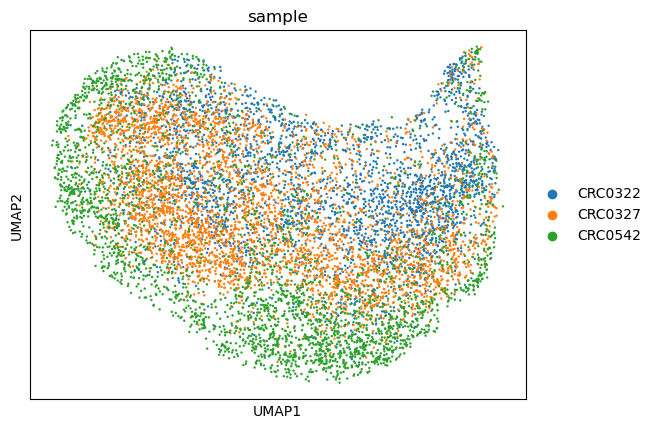

In [248]:
import scanpy as sc
import bbknn
sc.pp.pca(adata,random_state=42,n_comps=n_components_90,use_highly_variable=False)
bbknn.bbknn(adata, batch_key='sample')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['sample'])

saving figure to file figures/umap_clustering_r0.1.pdf


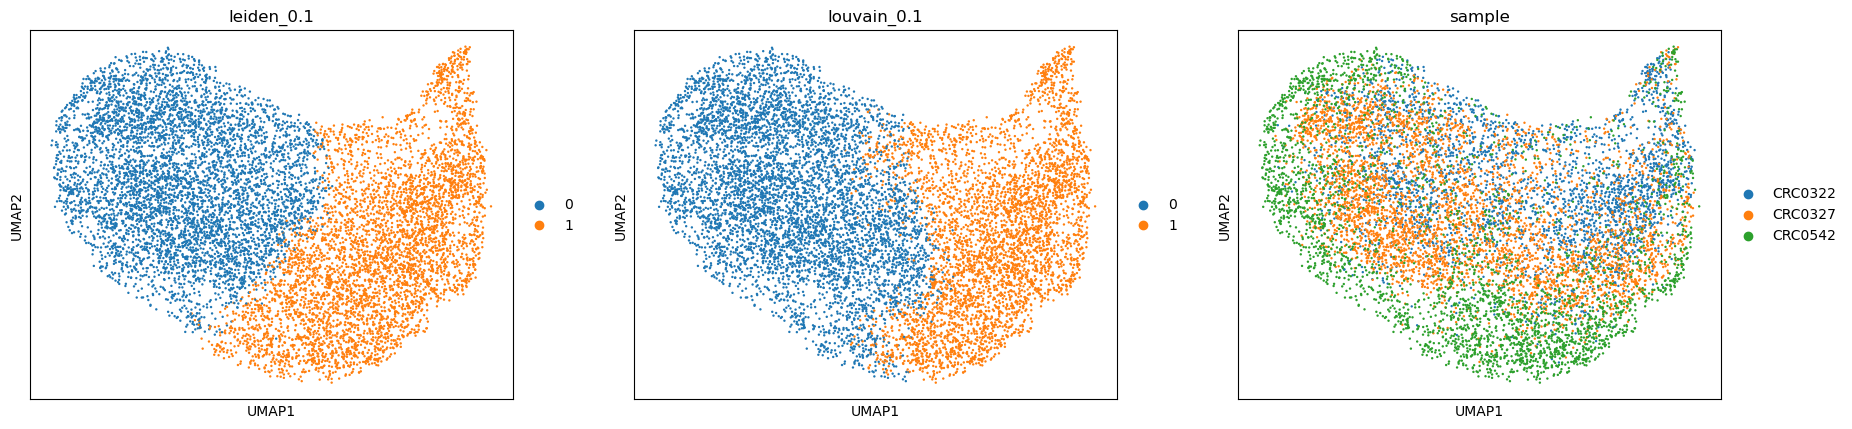

saving figure to file figures/umap_clustering_r0.3.pdf


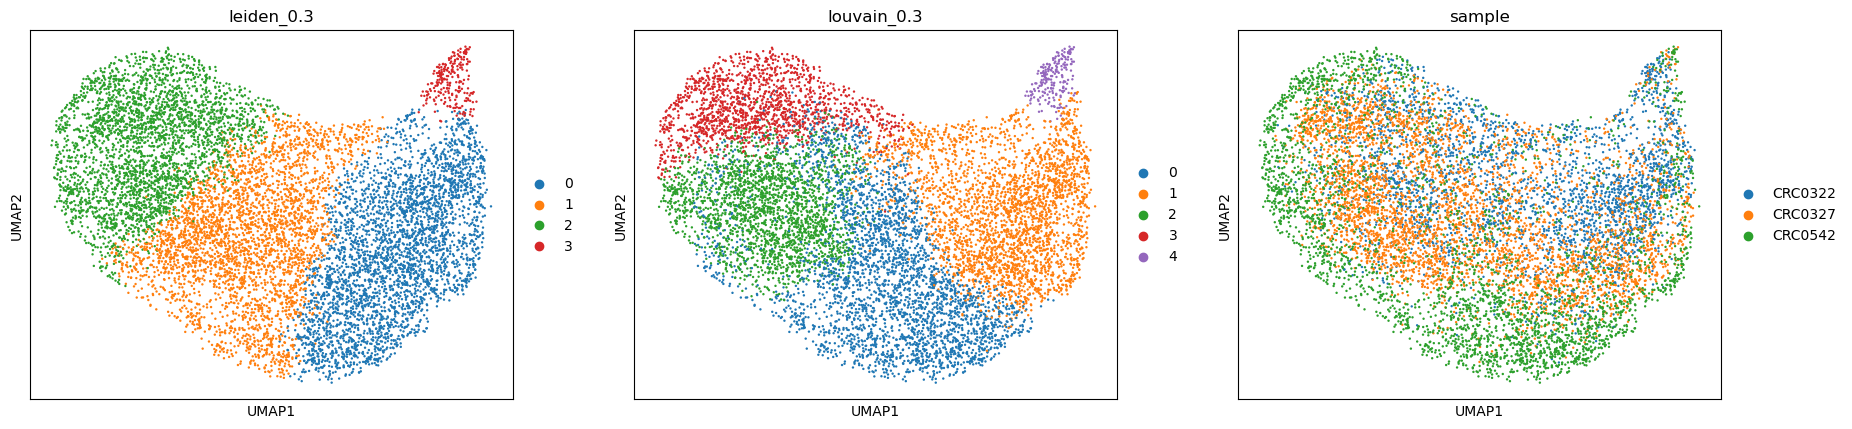

saving figure to file figures/umap_clustering_r0.4.pdf


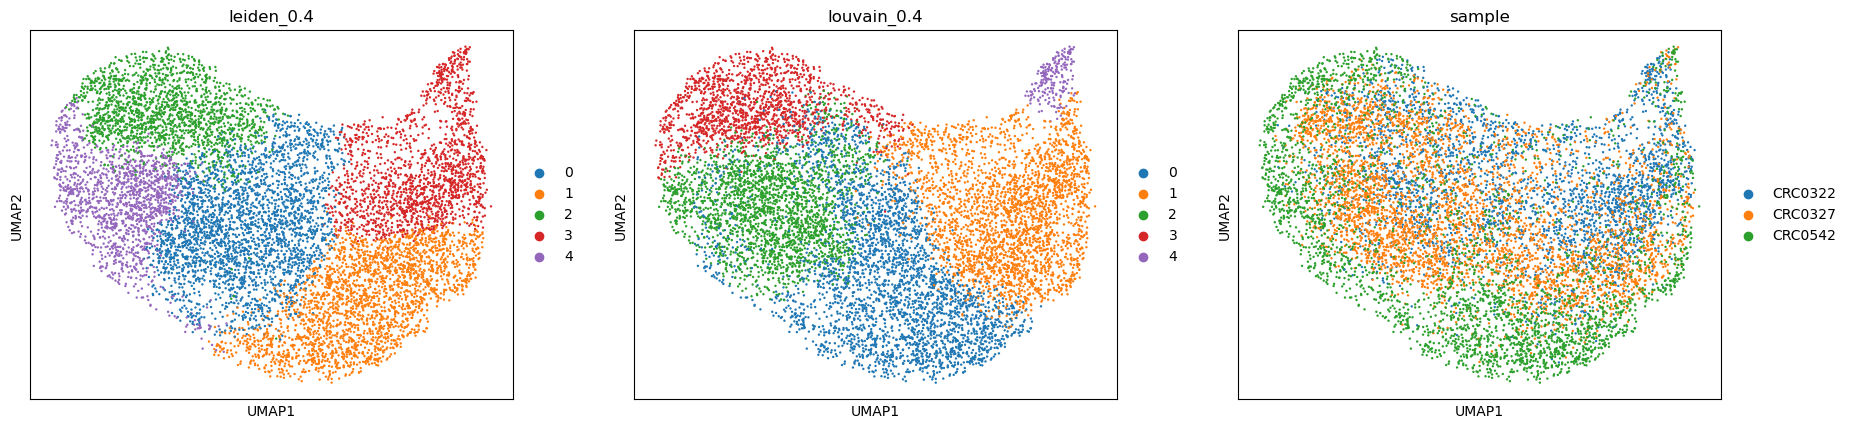

saving figure to file figures/umap_clustering_r0.5.pdf


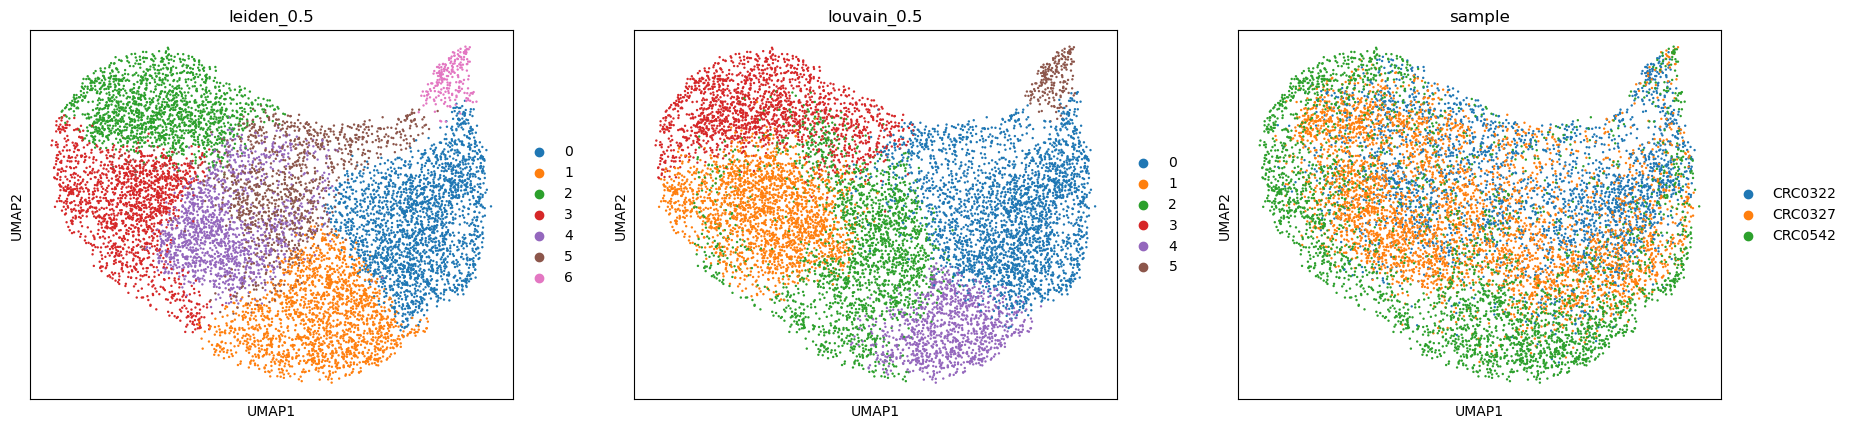

saving figure to file figures/umap_clustering_r0.6.pdf


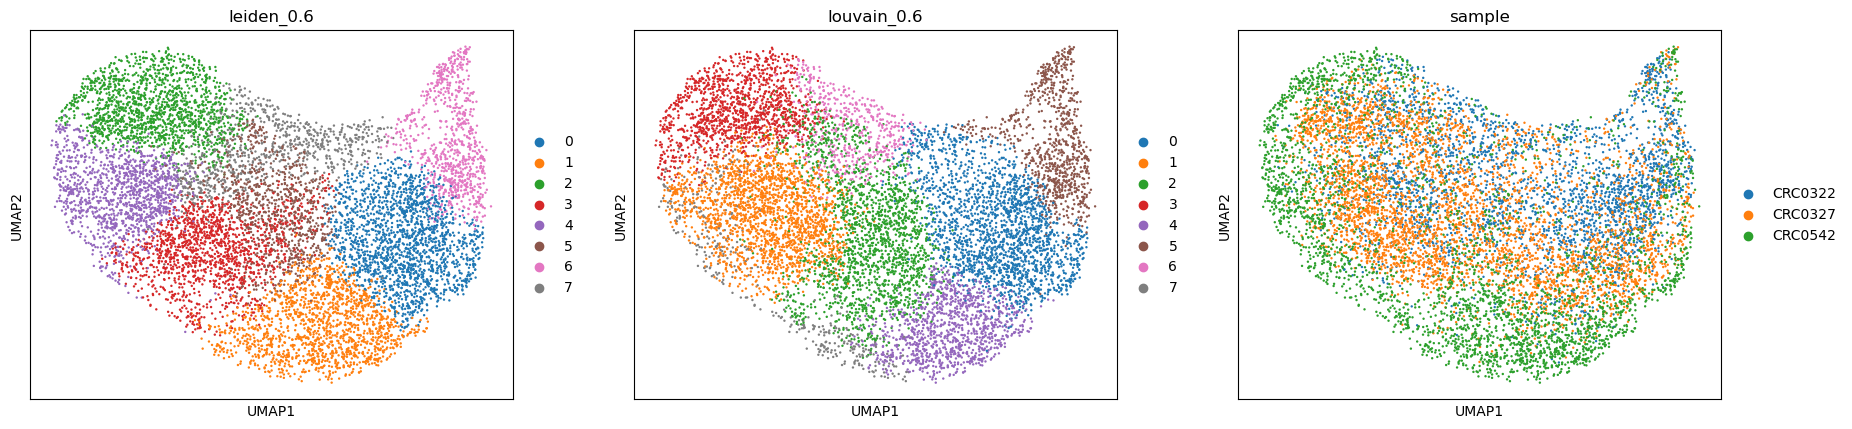

In [158]:
res = [0.1, 0.3, 0.4,0.5,0.6]

for r in res:
    leiden_key = f"leiden_{r}"
    louvain_key = f"louvain_{r}"

    sc.tl.leiden(adata, resolution=r, key_added=leiden_key)
    sc.tl.louvain(adata, resolution=r, key_added=louvain_key)


    filename = f"_clustering_r{r}.pdf"  # salverà in ./figures/
    sc.pl.umap(
        adata,
        color=[leiden_key, louvain_key, "sample"],
        save=filename,
        show=True  
    )



saving figure to file figures/rank_genes_groups_leiden_0.1_leiden_0.1.pdf


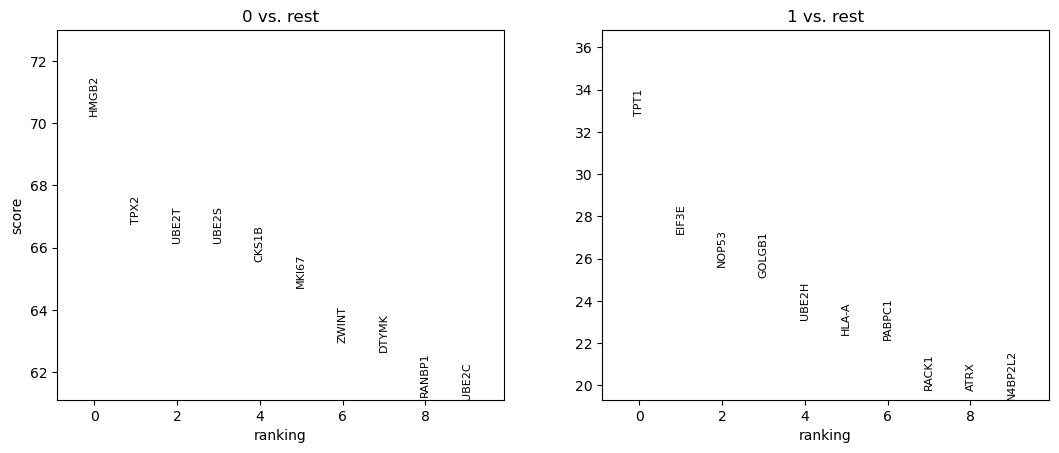

saving figure to file figures/rank_genes_groups_leiden_0.3_leiden_0.3.pdf


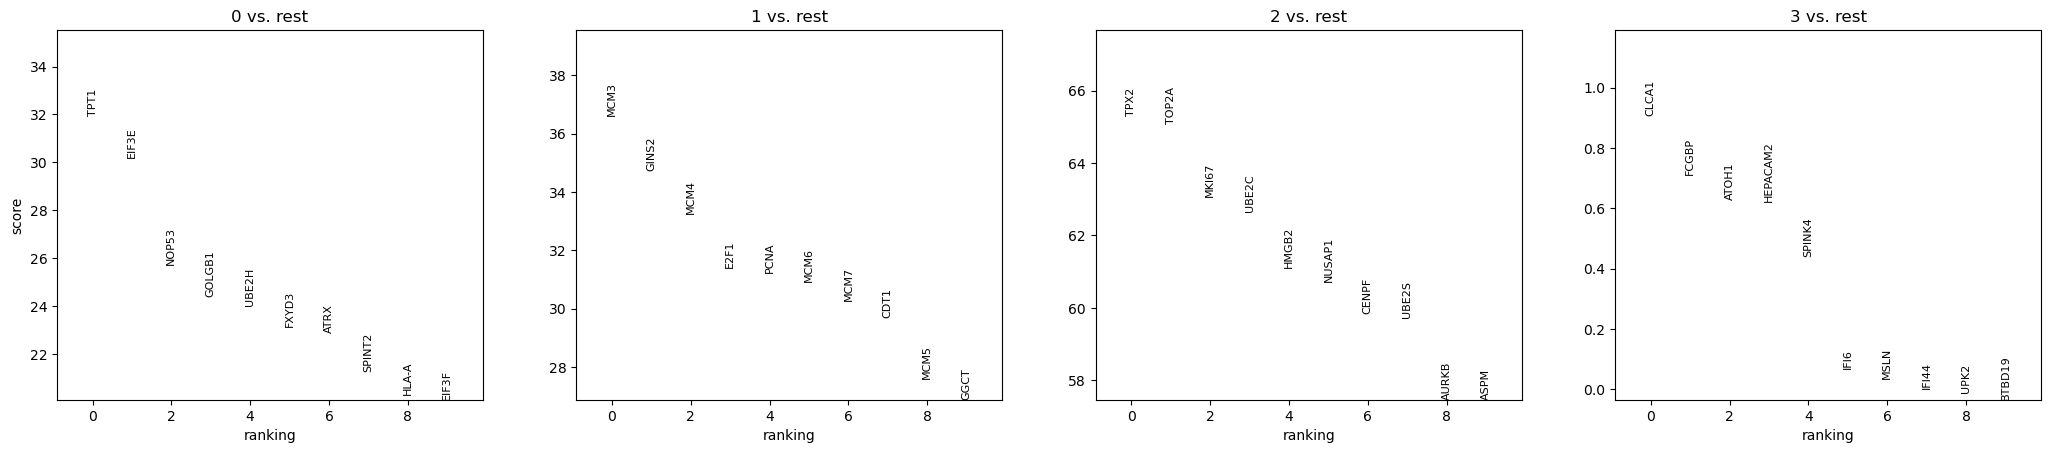

saving figure to file figures/rank_genes_groups_leiden_0.4_leiden_0.4.pdf


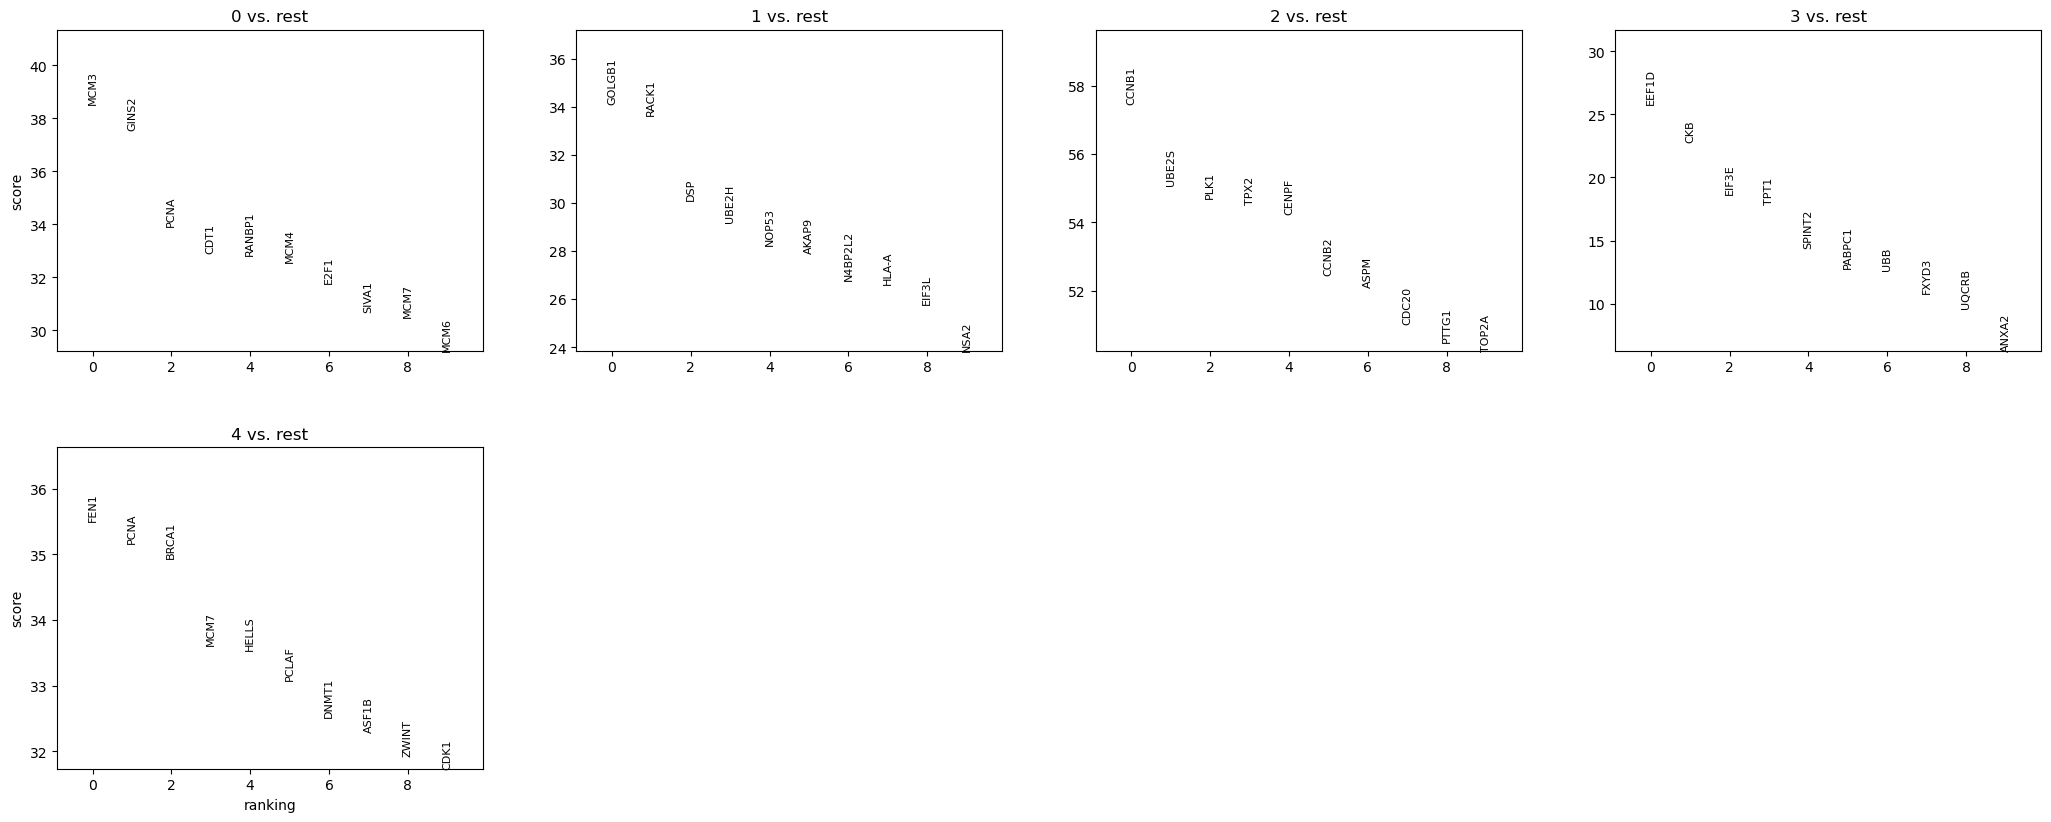

In [151]:
#Marker per Leiden
for r in res:
    key = f'leiden_{r}'
    rank_key = f'rank_{key}'
    sc.tl.rank_genes_groups(adata, groupby=key, method='wilcoxon', key_added=rank_key)
    sc.pl.rank_genes_groups(adata, key=rank_key, n_genes=10, sharey=False, save=f"_{key}.pdf")

saving figure to file figures/rank_genes_groups_louvain_0.1_louvain_0.1.pdf


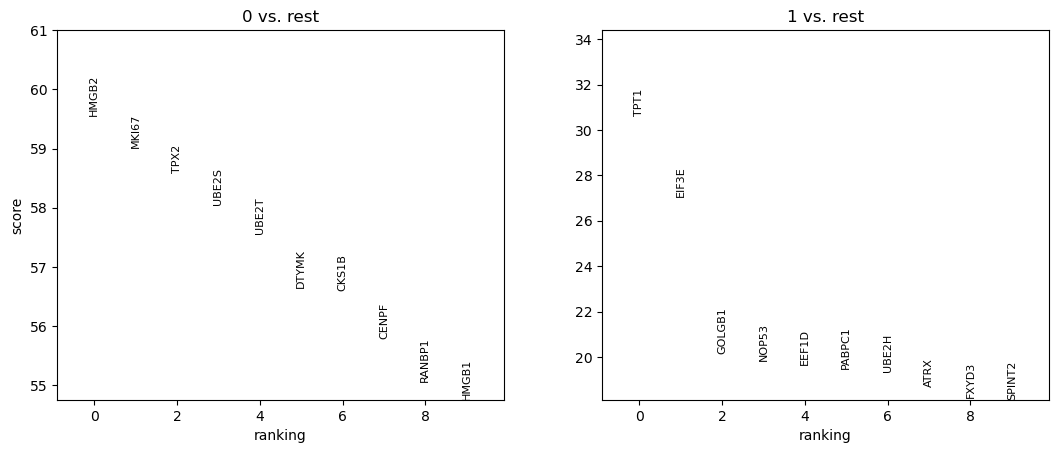

saving figure to file figures/rank_genes_groups_louvain_0.3_louvain_0.3.pdf


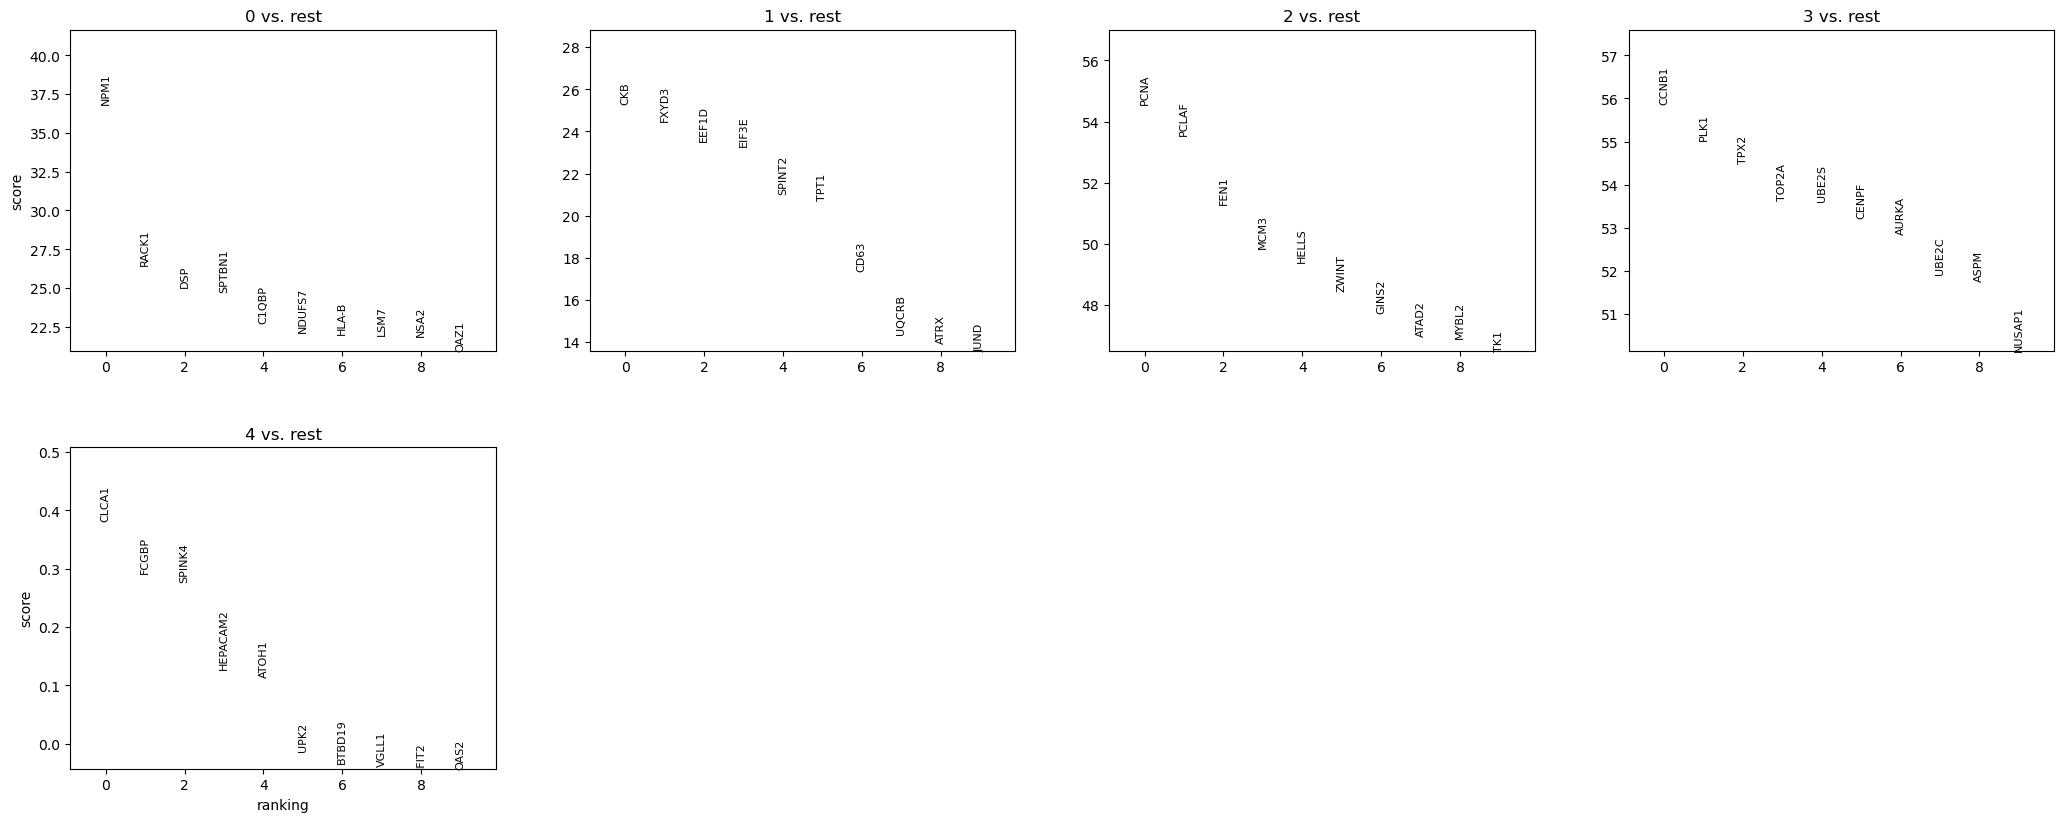

saving figure to file figures/rank_genes_groups_louvain_0.4_louvain_0.4.pdf


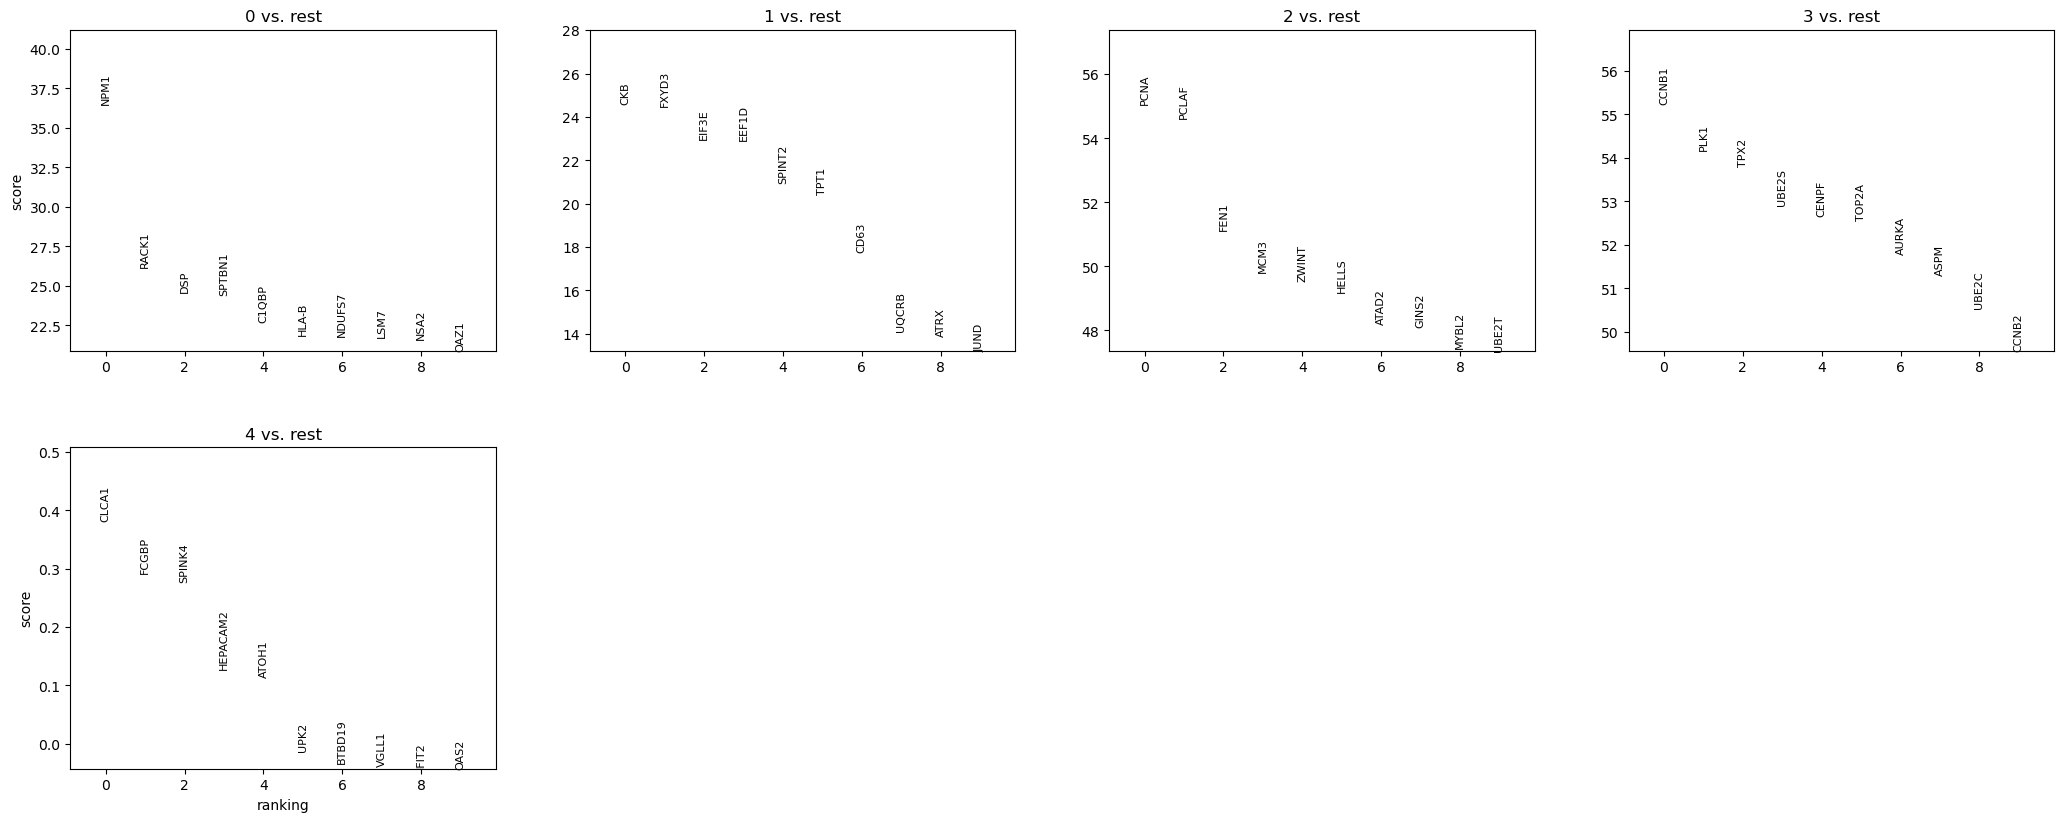

In [152]:
for r in res:
    key = f'louvain_{r}'
    rank_key = f'rank_{key}'
    sc.tl.rank_genes_groups(adata, groupby=key, method='wilcoxon', key_added=rank_key)
    sc.pl.rank_genes_groups(adata, key=rank_key, n_genes=10, sharey=False, save=f"_{key}.pdf")

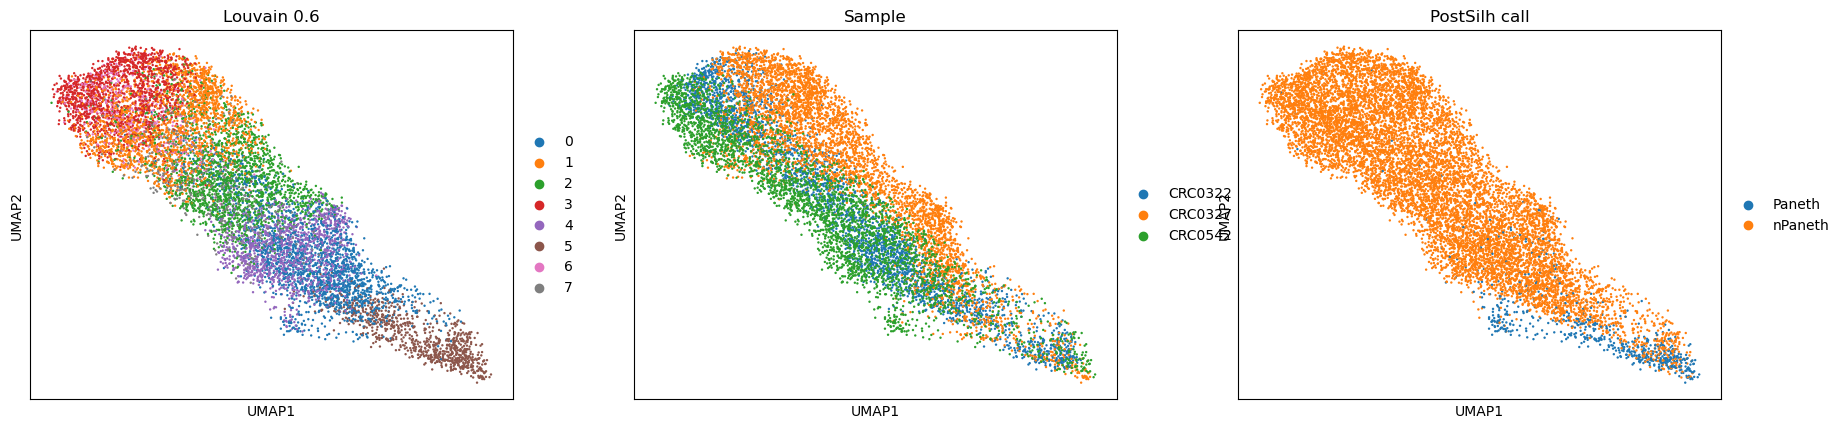

In [259]:
adata.obs['kmeans'] = paneth
sc.pl.umap(
    adata,
    color=['louvain_0.6', 'sample', 'Paneth'],
    na_color='black',
    title=['Louvain 0.6', 'Sample', 'PostSilh call'],
)


In [243]:
clust=pd.DataFrame(adata.obs['leiden_0.6'])

In [245]:
totale=pd.concat([clust,paneth],axis=1)
totale.columns=['clust','p']

In [246]:
totale.groupby(['clust', 'p']).size().unstack()

/tmp/ipykernel_930413/4009329152.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totale.groupby(['clust', 'p']).size().unstack()


p,Paneth,nPaneth
clust,,
0,186,1646
1,45,1466
2,1,1485
3,1,1460
4,3,1274
5,2,848
6,378,443
7,15,797


proviamo harmonca

In [249]:
pca_data = adata.obsm['X_pca']

ho = hm.run_harmony(pca_data, adata.obs, 'sample')  # 'sample' è il batch key

# Salva i nuovi embeddings integrati
adata.obsm['X_pca_harmony'] = ho.Z_corr.T 

2025-07-18 14:32:18,952 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-07-18 14:32:42,452 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-07-18 14:32:42,536 - harmonypy - INFO - Iteration 1 of 10
2025-07-18 14:33:41,258 - harmonypy - INFO - Iteration 2 of 10
2025-07-18 14:34:41,022 - harmonypy - INFO - Converged after 2 iterations


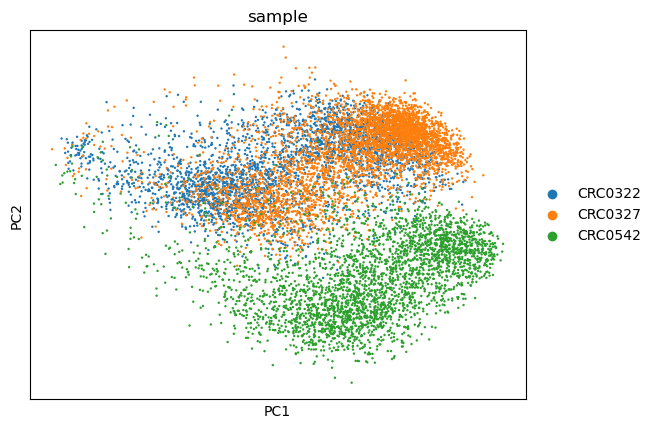

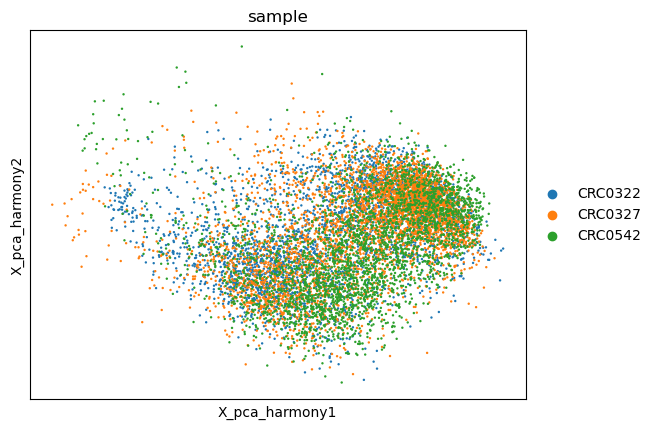

In [250]:
sc.pl.pca(adata, color='sample')  # pre-integrazione
sc.pl.embedding(adata, basis='X_pca_harmony', color='sample') 

In [267]:
sc.pp.neighbors(adata, use_rep='X_pca_harmony')

# UMAP e clustering
# sc.tl.umap(adata)
# sc.tl.leiden(adata,resolution=0.7)
# sc.pl.umap(adata, color=['leiden', 'sample','kmeans'])

In [294]:
sc.tl.leiden(adata, resolution=0.8, key_added='merda')


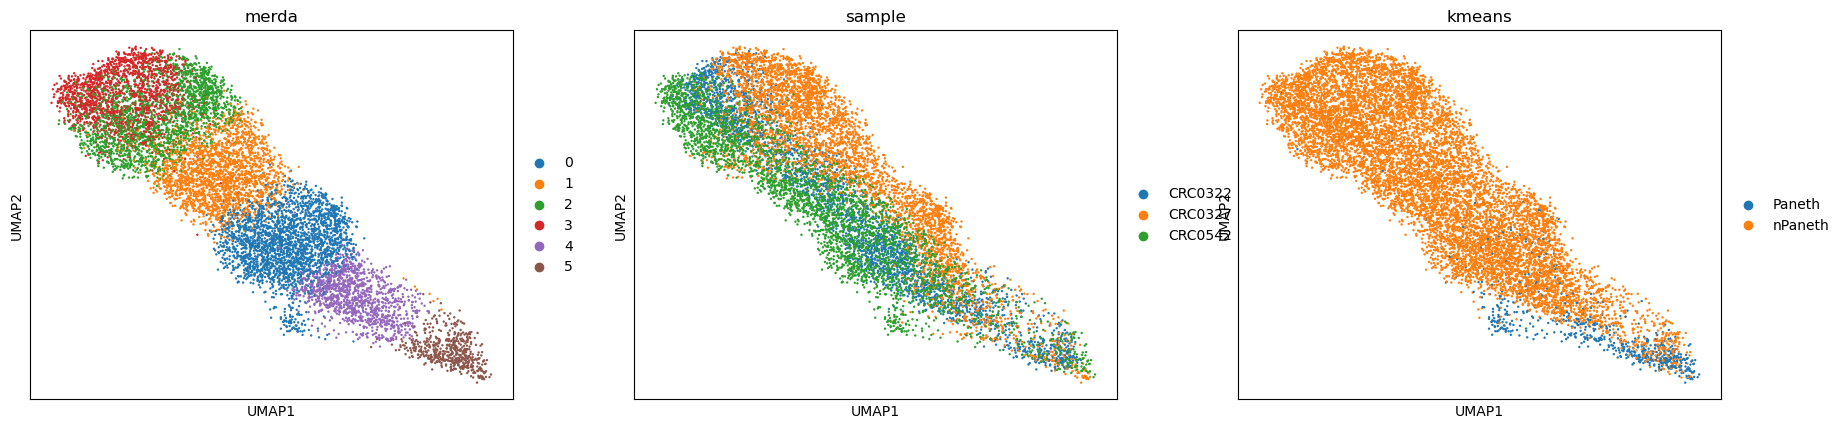

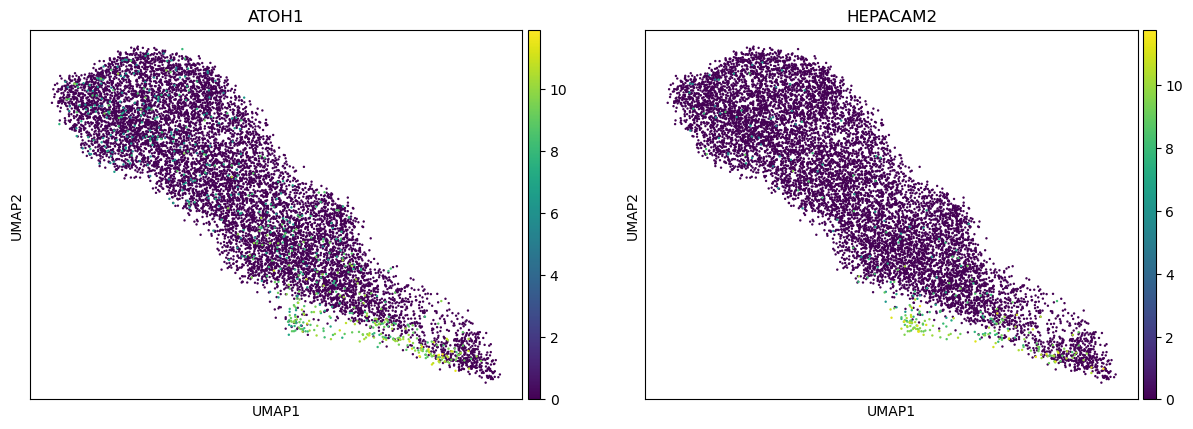

In [295]:
sc.pl.umap(adata, color=['merda','sample','kmeans'])
sc.pl.umap(adata, color=['ATOH1','HEPACAM2'])

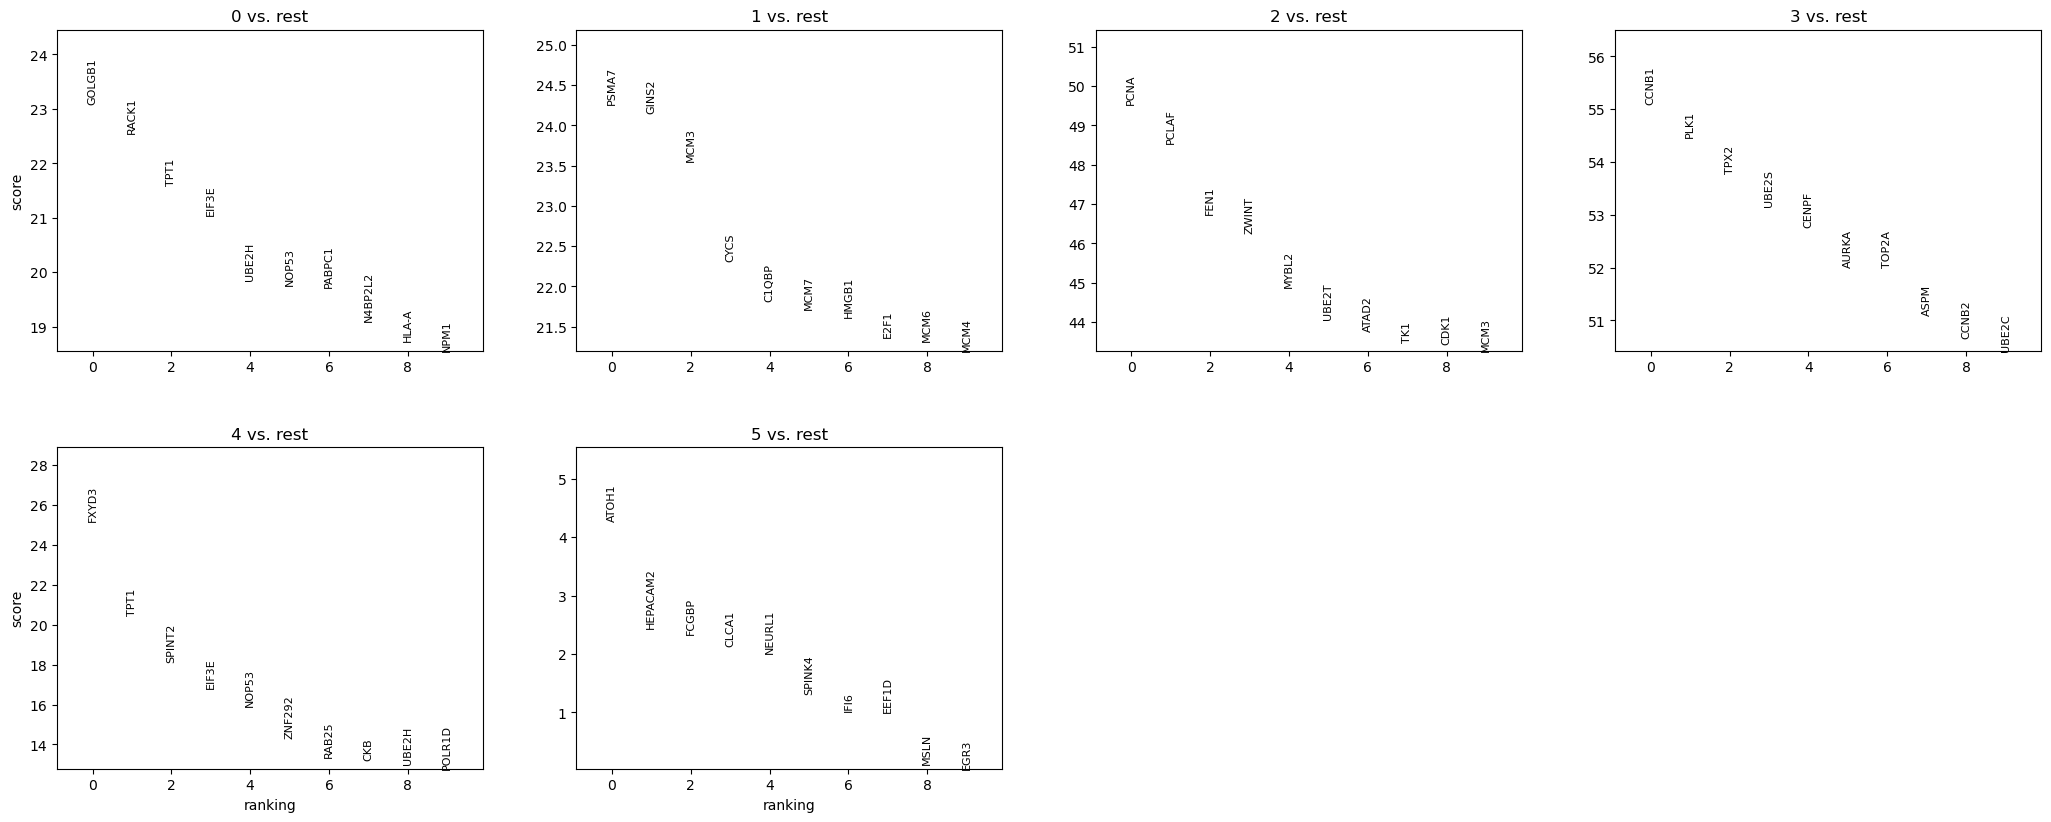

In [296]:
sc.tl.rank_genes_groups(adata, groupby='merda', method='wilcoxon', key_added='merda')
sc.pl.rank_genes_groups(adata, key='merda', n_genes=10, sharey=False)

In [293]:
clust=pd.DataFrame(adata.obs['leiden_0.8'])
totale=pd.concat([clust,paneth],axis=1)
totale.columns=['clust','p']
totale.groupby(['clust', 'p']).size().unstack()

/tmp/ipykernel_930413/3732862017.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totale.groupby(['clust', 'p']).size().unstack()


p,Paneth,nPaneth
clust,,
0,146,2324
1,9,2133
2,2,2086
3,8,1591
4,164,1064
5,302,221
